# Transformer

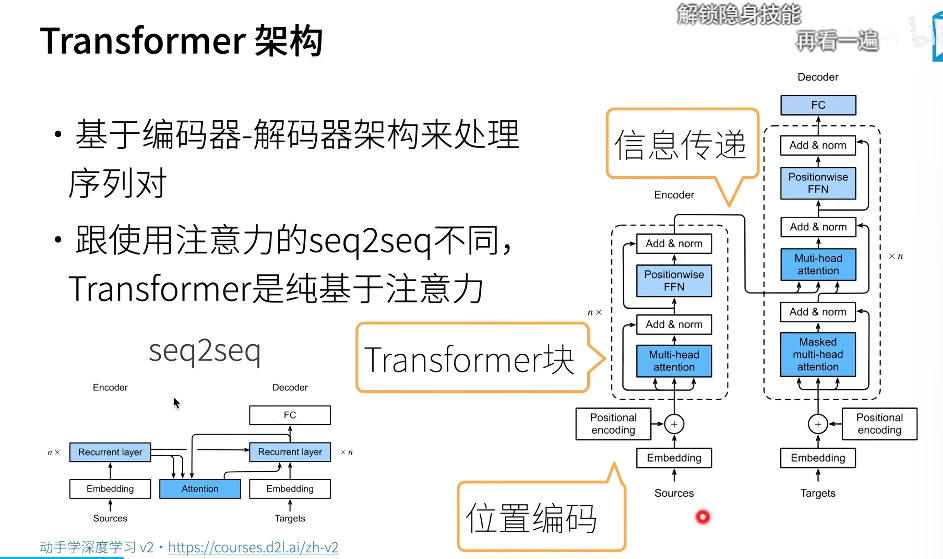

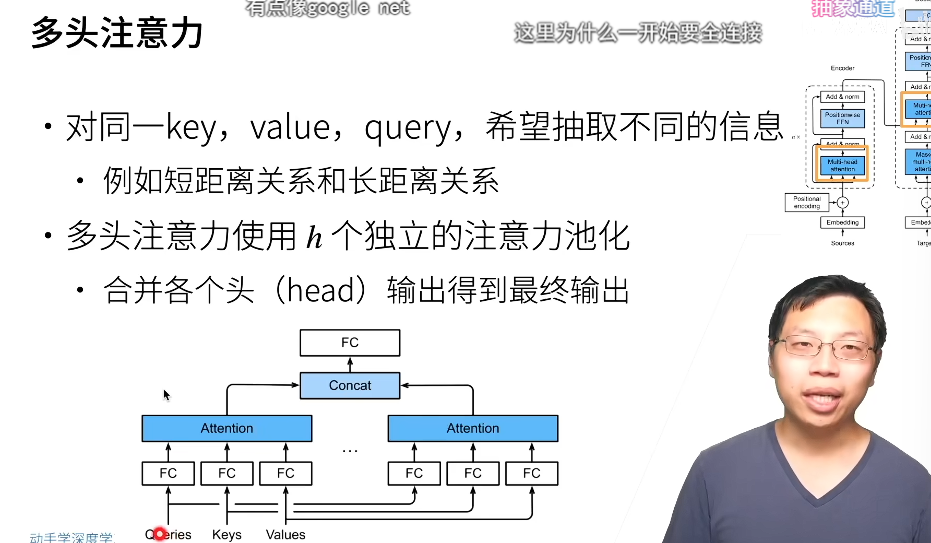

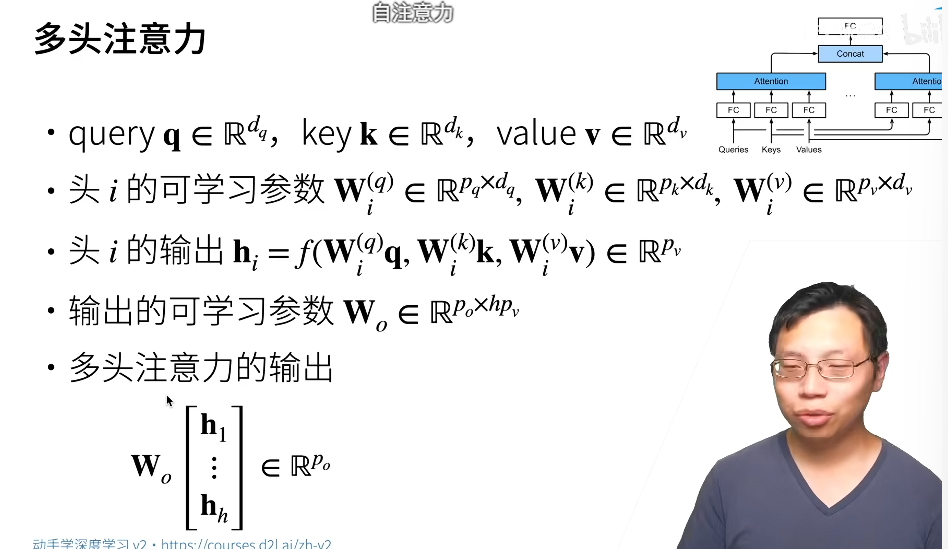

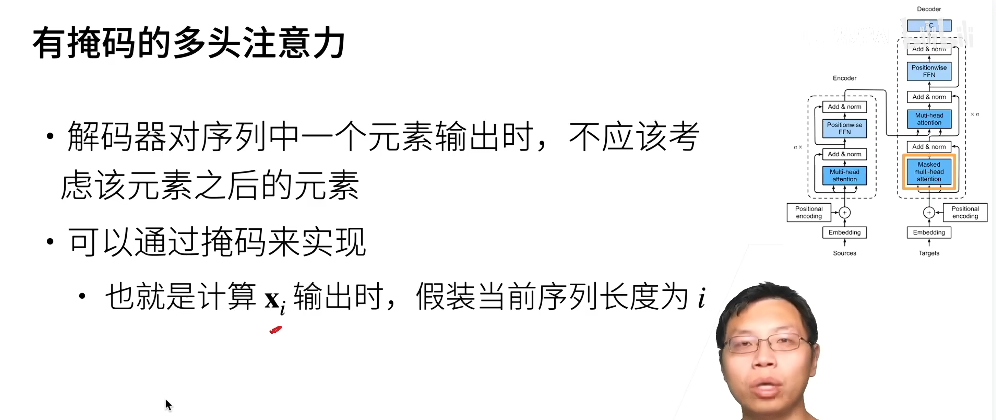

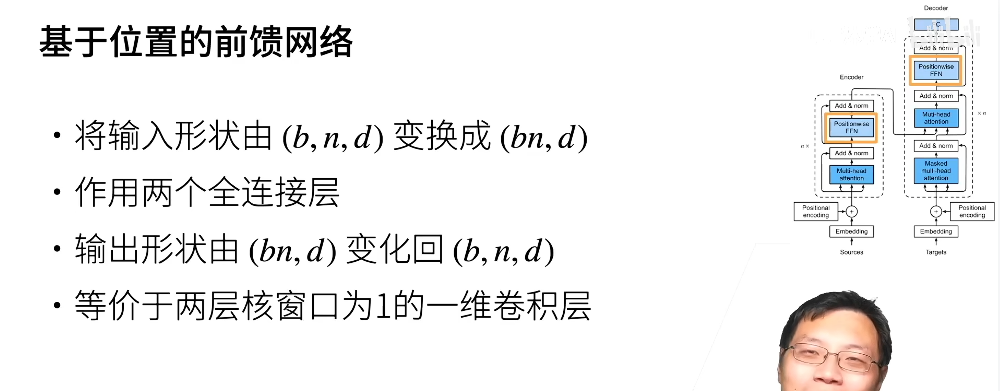

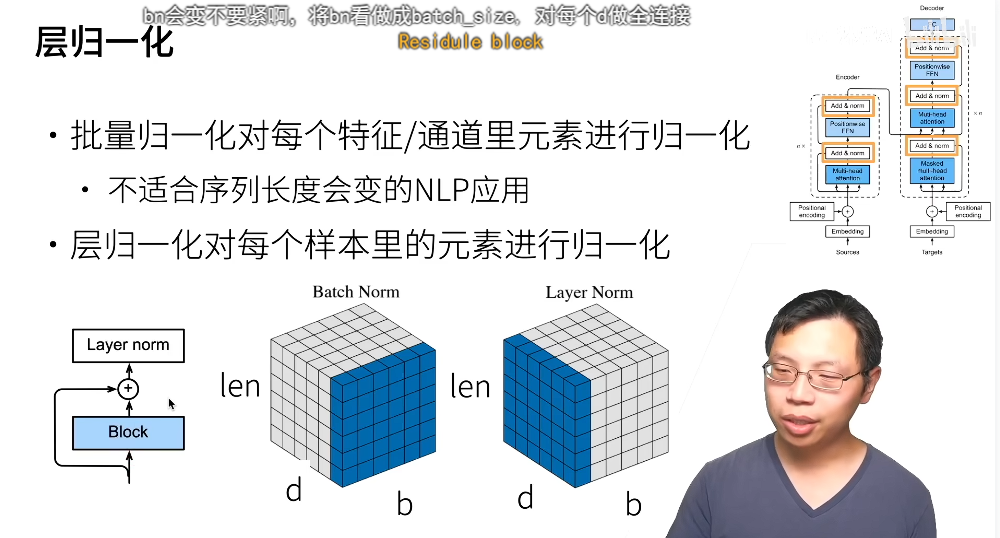

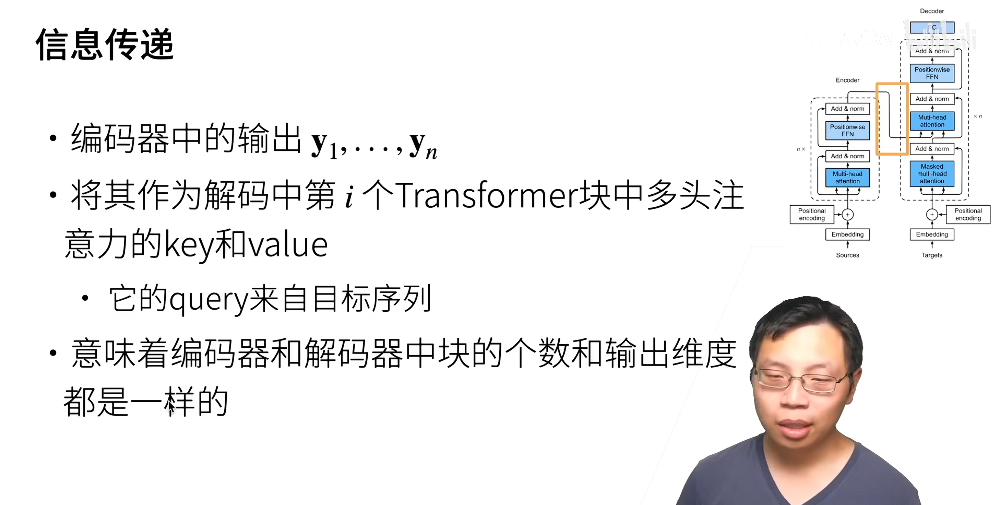

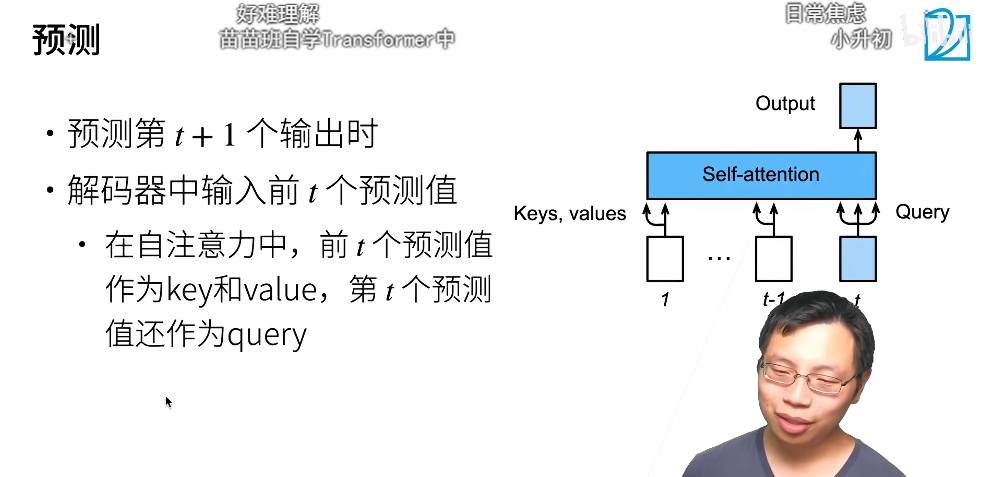

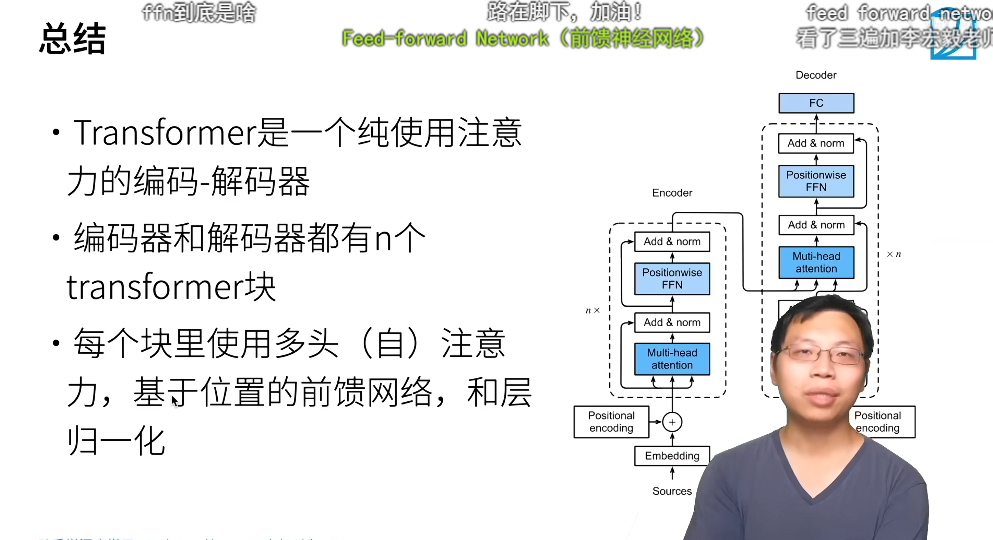

## 多头注意力代码

In [34]:
import math
import torch
from torch import nn
from d2l import torch as d2l

1. 先转换形状：按头数切割隐藏层，把多个头变成 batch 的一部分。

2. 然后整个进入attention里面同时对所有batch做attention

3. 最后逆转形状，拼接结果

In [35]:
#@save
class MultiHeadAttention(nn.Module):
    """多头注意力"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        # queries，keys，values的形状:
        # (batch_size，查询或者“键－值”对的个数，num_hiddens)
        # valid_lens　的形状:
        # (batch_size，)或(batch_size，查询的个数)
        # 经过变换后，输出的queries，keys，values　的形状:
        # (batch_size*num_heads，查询或者“键－值”对的个数，num_hiddens/num_heads)
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        # 有效长度个数变成 head 倍个，
        if valid_lens is not None:
            # 在轴0，将第一项（标量或者矢量）复制num_heads次，
            # 然后如此复制第二项，然后诸如此类。
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0)

        # output的形状:(batch_size*num_heads，查询的个数，num_hiddens/num_heads)
        output = self.attention(queries, keys, values, valid_lens)

        # output_concat的形状:(batch_size，查询的个数，num_hiddens)
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

transpose_qkv：

输入X的形状:(batch_size，查询或者“键－值”对的个数，num_hiddens)

输出的形状:(batch_size*num_heads,查询或者“键－值”对的个数,num_hiddens/num_heads)

In [36]:
#@save
def transpose_qkv(X, num_heads):
    """为了多注意力头的并行计算而变换形状"""
    # 输入X的形状:(batch_size，查询或者“键－值”对的个数，num_hiddens)
    # 输出X的形状:(batch_size，查询或者“键－值”对的个数，num_heads，num_hiddens/num_heads)
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)

    # 输出X的形状:(batch_size，num_heads，查询或者“键－值”对的个数,num_hiddens/num_heads)
    X = X.permute(0, 2, 1, 3)

    # 最终输出的形状:(batch_size*num_heads,查询或者“键－值”对的个数,num_hiddens/num_heads)
    return X.reshape(-1, X.shape[2], X.shape[3])
# 把多个头变成 batch 的一部分，让后面的点积注意力一次性并行算出所有头的结果

#@save
def transpose_output(X, num_heads):
    """逆转transpose_qkv函数的操作"""
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

In [37]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens,
                               num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

Q 变成：(2*5, 4, 20) = (10, 4, 20)（查询数 4 保留）

K / V 变成：(2*5, 6, 20) = (10, 6, 20)（键值对数 6 保留）

Q × K^T → (10, 4, 20) × (10, 20, 6) = (10, 4, 6)

Softmax 加权求和后，乘以 V(10, 6, 20) → 输出形状为 (10, 4, 20) → 恢复为 (2, 4, 100)

In [38]:
batch_size, num_queries = 2, 4
num_kvpairs, valid_lens =  6, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
# 2，4，100
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
# 2，6，100
attention(X, Y, Y, valid_lens).shape

torch.Size([2, 4, 100])

## transformer代码

In [39]:
import math
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

基于位置的前馈网络

In [40]:
#@save
class PositionWiseFFN(nn.Module):
# Position-wise 对每个位置的特征向量独立地做同样的线性变换。
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        # 线性层，将输入维度 ffn_num_input 放大到隐藏维度 ffn_num_hiddens
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        # 将隐藏维度再映射回输出维度 ffn_num_outputs
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))
        # X → 全连接1 → ReLU → 全连接2 → 输出

In [41]:
ffn = PositionWiseFFN(4, 4, 8) 
# 最后一维变成 8 → 形状变为 (2, 3, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]  
# (批量=2, 序列长度=3, 特征维度=4)取第 0 个批次的样本
# 最终得到的张量形状是 (3, 8)

tensor([[ 0.0652,  0.0380, -0.0945,  0.0233,  0.1868,  0.2827,  0.2073, -0.3619],
        [ 0.0652,  0.0380, -0.0945,  0.0233,  0.1868,  0.2827,  0.2073, -0.3619],
        [ 0.0652,  0.0380, -0.0945,  0.0233,  0.1868,  0.2827,  0.2073, -0.3619]],
       grad_fn=<SelectBackward0>)

残差连接和层规范化

In [42]:
ln = nn.LayerNorm(2)  # 每个样本归一化
bn = nn.BatchNorm1d(2)  # 每个特征归一化
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
# 在训练模式下计算X的均值和方差
print(X,'\nlayer norm:', ln(X), '\nbatch norm:', bn(X))

tensor([[1., 2.],
        [2., 3.]]) 
layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [43]:
#@save
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

残差连接和层归一化不会改变元素形状

In [44]:
# normalized_shape=[3, 4]，强制要求输入张量的最后两个维度必须精确等于 3 和 4
add_norm = AddNorm([3, 4], 0.5) 
# 每个位置有 50% 概率变成 0
add_norm.eval()  
# Dropout 处于评估模式，它不会丢弃任何神经元，
add_norm(torch.ones((2, 3, 4)), torch.ones((2, 3, 4))).shape
# 传入X\Y

torch.Size([2, 3, 4])

编码器

编码器块：自注意力 + 残差层归一化 + 前馈网络 + 残差层归一化

In [45]:
#@save
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = d2l.MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout,
            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(
            ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        # 自注意力+残差连接+归一化
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        # 前馈神经网络+归一化
        return self.addnorm2(Y, self.ffn(Y))

Transformer编码器中的任何层都不会改变其输入的形状

In [46]:
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3, 2])
encoder_blk = EncoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5)
encoder_blk.eval()
encoder_blk(X, valid_lens).shape

torch.Size([2, 100, 24])

编码器：EncoderBlock + PositionalEncoding + MultiHeadAttention

In [ ]:
#@save
class TransformerEncoder(d2l.Encoder):
    """Transformer编码器"""
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        # 词嵌入
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        # 位置编码
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        # 编码器块
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        # 因为位置编码值在-1和1之间，嵌入值通常小于1
        # 若直接相加，位置编码会淹没掉词嵌入的语义信息
        # 因此嵌入值乘以嵌入维度的平方根进行缩放，
        # 然后再与位置编码相加。
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        # 编码器块逐层传递
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            # 捕获注意力权重，将每一层的最后一个注意力头的权重矩阵保存下来。
            self.attention_weights[
                i] = blk.attention.attention.attention_weights
        return X

In [48]:
encoder = TransformerEncoder(
    200, 24, 24, 24, 24, [100, 24], 24, 48, 8, 2, 0.5)
encoder.eval()
encoder(torch.ones((2, 100), dtype=torch.long), valid_lens).shape

torch.Size([2, 100, 24])

解码器

self.attention1（自注意力）self.attention2（交叉注意力）self.ffn（前馈网络）3 层子网络 和 状态缓存机制

既能高效并行训练（Teacher Forcing + 因果掩码）

又能高效串行推理（KV 缓存）

In [ ]:
class DecoderBlock(nn.Module):
    """解码器中第i个块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = d2l.MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = d2l.MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens,
                                   num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
    # state：[enc_outputs, enc_valid_lens, dec_state_cache]
        enc_outputs, enc_valid_lens = state[0], state[1]
        # 训练阶段，输出序列的所有词元都在同一时间处理，
        # 因此state[2][self.i]初始化为None。
        # 预测阶段，输出序列是通过词元一个接着一个解码的，
        # 因此state[2][self.i]包含着直到当前时间步第i个块解码的输出表示
        if state[2][self.i] is None:
            key_values = X
        else:
            # 拼接 KV 缓存，前一步的 K/V和当前步的 X拼在一起
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
# 这样第 2 步的注意力就能看到前 1 步的词，从而避免重复计算前面的注意力分数，显著加速推理。
        
        if self.training:
            batch_size, num_steps, _ = X.shape
            # 因果掩码 dec_valid_lens的开头:(batch_size,num_steps),
            # 其中每一行是[1,2,...,num_steps]
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        # 自注意力
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        # 残差归一化
        Y = self.addnorm1(X, X2)
        # 编码器－解码器注意力，交叉注意力
        # enc_outputs的开头:(batch_size,num_steps,num_hiddens)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        # 残差归一化2
        Z = self.addnorm2(Y, Y2)
        #FFN + 残差+层归一化 3
        return self.addnorm3(Z, self.ffn(Z)), state

In [50]:
decoder_blk = DecoderBlock(24, 24, 24, 24, [100, 24], 24, 48, 8, 0.5, 0)
decoder_blk.eval()
X = torch.ones((2, 100, 24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
decoder_blk(X, state)[0].shape

torch.Size([2, 100, 24])

嵌入、位置编码、多层解码块、输出投影串联成一个完整的自回归生成管道。

它通过 state 在层间传递并维护 KV 缓存

当 forward 返回时，state 中已经保存了所有层最新的缓存，可以直接用于下一步的推理（即生成第 t+1 个词）

实现了训练时的高效并行（因果掩码）和推理时的快速串行（缓存复用

In [ ]:
class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block"+str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        # 嵌入 + 位置编码
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range (2)]
        # 循环 num_layers 个 DecoderBlock
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            # 解码器自注意力权重
            self._attention_weights[0][
                i] = blk.attention1.attention.attention_weights
            # “编码器－解码器”自注意力权重
            self._attention_weights[1][
                i] = blk.attention2.attention.attention_weights
        # 输出投影
        return self.dense(X), state

    @property
    def attention_weights(self): # 注意力权重捕获
        return self._attention_weights

训练

loss 0.031, 1729.7 tokens/sec on cpu


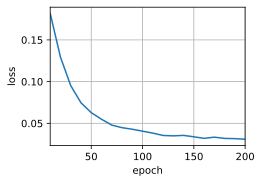

In [ ]:
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs, device = 0.005, 200, d2l.try_gpu()
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]

# 数据加载
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

# Embedding(32维) + PosEncoding + 2层 EncoderBlock
encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
# Embedding + PosEncoding + 2层 DecoderBlock
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)
# 组装
net = d2l.EncoderDecoder(encoder, decoder)
# 训练循环
d2l.train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

预测

In [53]:
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, ',
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va !,  bleu 1.000
i lost . => j'ai perdu .,  bleu 1.000
he's calm . => il est paresseux .,  bleu 0.658
i'm home . => je suis chez moi .,  bleu 1.000


enc_attention_weights是编码器自注意力权重，在编码源语言句子时，每个词（Query）是如何关注（分配注意力）到句子中其他所有词（Key）的

 (层数, 头数, 批量展平的查询位置, 键位置)

In [54]:
enc_attention_weights = torch.cat(net.encoder.attention_weights, 0).reshape((num_layers, num_heads,
    -1, num_steps))
enc_attention_weights.shape

torch.Size([2, 4, 10, 10])

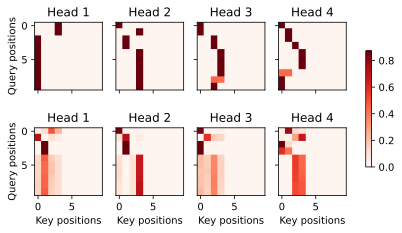

In [55]:
d2l.show_heatmaps(
    enc_attention_weights.cpu(), xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))

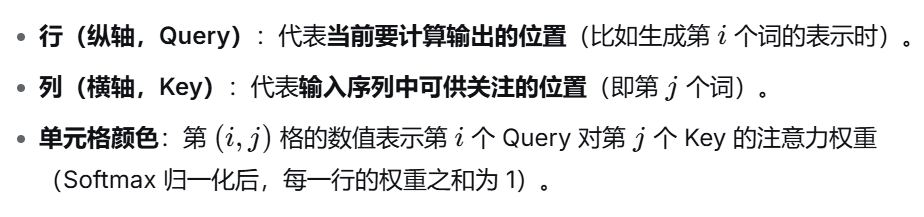

dec_self_attention_weights（解码器自注意力）：(层数, 头数, 目标生成步数, 目标历史步数)

dec_inter_attention_weights（编码器-解码器交叉注意力）：(层数, 头数, 目标生成步数, 源语言步数)

In [56]:
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weight_seq
                            for attn in step for blk in attn for head in blk]
dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)
dec_attention_weights = dec_attention_weights_filled.reshape((-1, 2, num_layers, num_heads, num_steps))
dec_self_attention_weights, dec_inter_attention_weights = \
    dec_attention_weights.permute(1, 2, 3, 0, 4)
dec_self_attention_weights.shape, dec_inter_attention_weights.shape

(torch.Size([2, 4, 6, 10]), torch.Size([2, 4, 6, 10]))

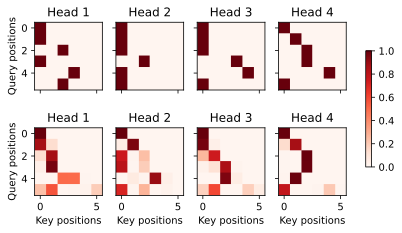

In [57]:
# Plusonetoincludethebeginning-of-sequencetoken
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :len(translation.split()) + 1],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)], figsize=(7, 3.5))

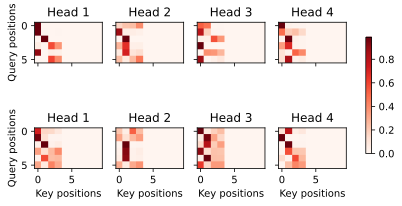

In [58]:
d2l.show_heatmaps(
    dec_inter_attention_weights, xlabel='Key positions',
    ylabel='Query positions', titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))